In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)
df = pd.read_csv("CKD_preprocessed_patient_level.csv")
TARGET = "CKD (1-yes, 0-no)"

In [2]:
#  Validation guards
if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found.")

if "Patient ID" in df.columns:
    raise ValueError(
        "Patient ID is still present. Remove Patient ID before modeling."
    )
if df.isnull().sum().sum() > 0:
    raise ValueError("Missing values detected in the dataset.")

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy    = accuracy_score(y_test, y_pred)
precision   = precision_score(y_test, y_pred, zero_division=0)
recall      = recall_score(y_test, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1          = f1_score(y_test, y_pred, zero_division=0)
roc_auc     = roc_auc_score(y_test, y_prob)
pr_auc      = average_precision_score(y_test, y_prob)

print("\n" + "=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1 Score    : {f1:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")
print(f"PR-AUC      : {pr_auc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")

print(classification_report(y_test, y_pred,
                            target_names=["No CKD", "CKD"], zero_division=0))



Training samples: 280
Testing samples : 120

RANDOM FOREST RESULTS
Accuracy    : 0.7000
Precision   : 0.6667
Recall      : 0.6909
Specificity : 0.7077
F1 Score    : 0.6786
ROC-AUC     : 0.8224
PR-AUC      : 0.7872

Confusion Matrix:
[[46 19]
 [17 38]]

Classification Report:
              precision    recall  f1-score   support

      No CKD       0.73      0.71      0.72        65
         CKD       0.67      0.69      0.68        55

    accuracy                           0.70       120
   macro avg       0.70      0.70      0.70       120
weighted avg       0.70      0.70      0.70       120



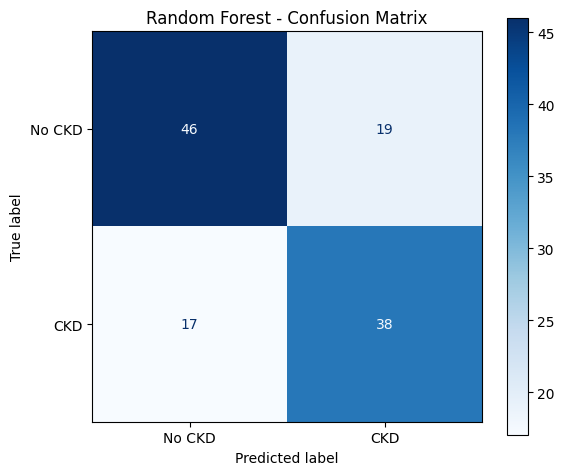

In [3]:
#  Confusion matrix plot
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No CKD", "CKD"],
    cmap="Blues", values_format="d", ax=ax
)
ax.set_title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

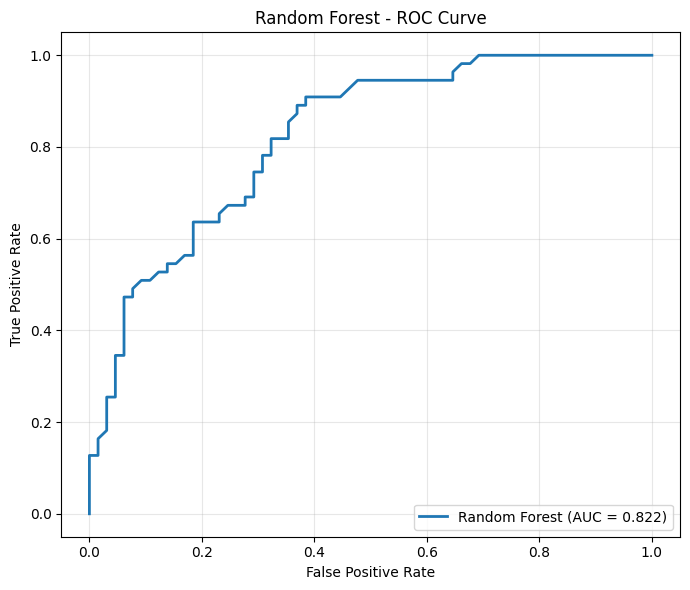

In [4]:
#  ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, linewidth=2, label=f"Random Forest (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Random Forest - ROC Curve")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



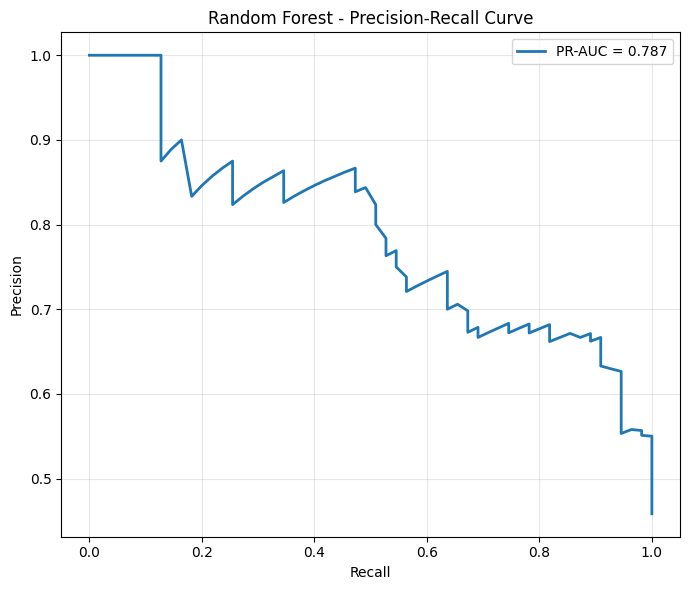

In [5]:
#  Precision-Recall curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall_curve, precision_curve, linewidth=2,
        label=f"PR-AUC = {pr_auc:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Random Forest - Precision-Recall Curve")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

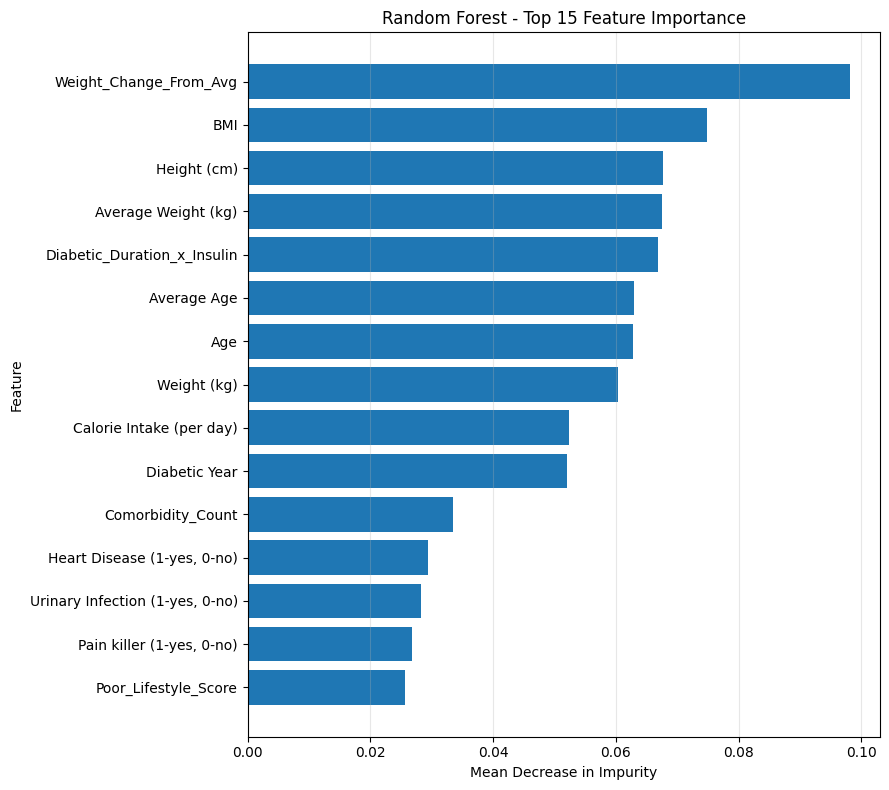


Top 15 Random Forest Features:
                        Feature  Importance
         Weight_Change_From_Avg    0.098139
                            BMI    0.074930
                    Height (cm)    0.067762
            Average Weight (kg)    0.067589
    Diabetic_Duration_x_Insulin    0.066907
                    Average Age    0.063015
                            Age    0.062724
                    Weight (kg)    0.060424
       Calorie Intake (per day)    0.052399
                  Diabetic Year    0.052070
              Comorbidity_Count    0.033429
    Heart Disease (1-yes, 0-no)    0.029458
Urinary Infection (1-yes, 0-no)    0.028308
      Pain killer (1-yes, 0-no)    0.026844
           Poor_Lifestyle_Score    0.025717


In [6]:
# FEATURE IMPORTANCE

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=True)

top_features = importance.tail(15)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top_features["Feature"], top_features["Importance"])
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_ylabel("Feature")
ax.set_title("Random Forest - Top 15 Feature Importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
print("\nTop 15 Random Forest Features:")
print(
    importance
    .sort_values("Importance", ascending=False)
    .head(15)
    .to_string(index=False)
)
